In [1]:
import transformers
import torch

print("Transformers version:", transformers.__version__)
print("PyTorch version:", torch.__version__)
print("Libraries ready.")

Transformers version: 5.16.1
PyTorch version: 2.13.0+cpu
Libraries ready.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from transformers import pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
data_path = Path("../data/processed/multilingual_toxicity_processed.csv")

df = pd.read_csv(data_path)

print("Processed dataset loaded successfully.")
print("=" * 50)

print(f"Total samples: {len(df):,}")

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Processed dataset loaded successfully.
Total samples: 71,374

Columns:
['text', 'toxic', 'language_code', 'language', 'text_length', 'clean_text']

First 5 rows:


,text,toxic,language_code,language,text_length,clean_text
0,The trans women reading this tweet right now i...,0,en,English,57,The trans women reading this tweet right now i...
1,9) uhhhh i like being lgbt a lot. i feel proud...,0,en,English,97,9) uhhhh i like being lgbt a lot. i feel proud...
2,Hero Rohit Sharma love From Pakistan,0,en,English,36,Hero Rohit Sharma love From Pakistan
3,As a slightly feminine top I appreciate all ma...,0,en,English,82,As a slightly feminine top I appreciate all ma...
4,Delon Love Turkey and brave Turks from Indian ...,0,en,English,87,Delon Love Turkey and brave Turks from Indian ...


In [4]:
print("Toxicity label distribution")
print("=" * 50)

print(df["toxic"].describe())

print("\nLabel examples:")
print(df[["clean_text", "toxic", "language"]].head(10))

Toxicity label distribution
count    71374.000000
mean         0.497478
std          0.499997
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: toxic, dtype: float64

Label examples:
                                          clean_text  toxic language
0  The trans women reading this tweet right now i...      0  English
1  9) uhhhh i like being lgbt a lot. i feel proud...      0  English
2               Hero Rohit Sharma love From Pakistan      0  English
3  As a slightly feminine top I appreciate all ma...      0  English
4  Delon Love Turkey and brave Turks from Indian ...      0  English
5  Because it's the Word of God maybe? Just spitb...      0  English
6               God Bless From a Trinidadian Muslim!      0  English
7  Majority of girls talking to me after they fin...      0  English
8  Nice! As a bi couple, we thoroughly enjoy bi d...      0  English
9  Dark skinned men wearing pink shirts always ma...      0  

In [5]:
df["toxicity_label"] = (
    df["toxic"] >= 0.5
).astype(int)

print("Binary toxicity labels created.")

print(
    df["toxicity_label"]
    .value_counts()
    .sort_index()
)

Binary toxicity labels created.
toxicity_label
0    35867
1    35507
Name: count, dtype: int64


In [6]:
MODEL_NAME = "textdetox/bert-multilingual-toxicity-classifier"

toxicity_classifier = pipeline(
    "text-classification",
    model=MODEL_NAME
)

print("HumanLens multilingual toxicity model loaded.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

HumanLens multilingual toxicity model loaded.


In [7]:
test_texts = [
    "You are doing a wonderful job.",
    "I really hate you.",
    "You are stupid.",
    "तुम बहुत अच्छे हो।",
    "तुम बेवकूफ हो।",
    "Tu bahut stupid hai.",
    "Mujhe tumhara kaam bahut achha laga."
]

results = toxicity_classifier(
    test_texts
)

for text, result in zip(test_texts, results):
    print(f"Text: {text}")
    print(f"Prediction: {result}")
    print("-" * 60)

Text: You are doing a wonderful job.
Prediction: {'label': 'LABEL_0', 'score': 0.9957453608512878}
------------------------------------------------------------
Text: I really hate you.
Prediction: {'label': 'LABEL_0', 'score': 0.951399028301239}
------------------------------------------------------------
Text: You are stupid.
Prediction: {'label': 'LABEL_1', 'score': 0.9981665015220642}
------------------------------------------------------------
Text: तुम बहुत अच्छे हो।
Prediction: {'label': 'LABEL_1', 'score': 0.7377597093582153}
------------------------------------------------------------
Text: तुम बेवकूफ हो।
Prediction: {'label': 'LABEL_1', 'score': 0.9947821497917175}
------------------------------------------------------------
Text: Tu bahut stupid hai.
Prediction: {'label': 'LABEL_1', 'score': 0.9934642910957336}
------------------------------------------------------------
Text: Mujhe tumhara kaam bahut achha laga.
Prediction: {'label': 'LABEL_0', 'score': 0.859768807888031}
--

In [8]:
def get_toxicity_score(result):
    """
    Convert classifier output into a toxicity probability.
    """

    if result["label"].lower() in ["toxic", "label_1", "1"]:
        return float(result["score"])

    return float(1 - result["score"])

In [9]:
for text, result in zip(test_texts, results):

    score = get_toxicity_score(result)

    print(f"Text: {text}")
    print(f"Toxicity score: {score:.4f}")
    print("-" * 60)

Text: You are doing a wonderful job.
Toxicity score: 0.0043
------------------------------------------------------------
Text: I really hate you.
Toxicity score: 0.0486
------------------------------------------------------------
Text: You are stupid.
Toxicity score: 0.9982
------------------------------------------------------------
Text: तुम बहुत अच्छे हो।
Toxicity score: 0.7378
------------------------------------------------------------
Text: तुम बेवकूफ हो।
Toxicity score: 0.9948
------------------------------------------------------------
Text: Tu bahut stupid hai.
Toxicity score: 0.9935
------------------------------------------------------------
Text: Mujhe tumhara kaam bahut achha laga.
Toxicity score: 0.1402
------------------------------------------------------------


In [10]:
humanlens_test_cases = [
    ("English", "You are an idiot."),
    ("English", "Thank you for helping me."),
    
    ("Hindi", "तुम बहुत बेवकूफ हो।"),
    ("Hindi", "आपने मेरी बहुत मदद की।"),
    
    ("Hinglish", "Tu bahut stupid hai."),
    ("Hinglish", "Bhai tumne bahut achha kaam kiya."),

    ("Hinglish", "Teri maa ke chhole kulche kha jaunga."),
    ("Hinglish", "Teri maa ka bhosda , sale dalle ki aulad."),

    ("English", "Fuck you"),
    ("Hinglish", "Teri maa ki chut sare")
     
]

test_results = []

for language, text in humanlens_test_cases:

    result = toxicity_classifier(text)[0]

    score = get_toxicity_score(result)

    test_results.append({
        "language": language,
        "text": text,
        "model_label": result["label"],
        "toxicity_score": score
    })

test_results_df = pd.DataFrame(test_results)

display(test_results_df)

,language,text,model_label,toxicity_score
0,English,You are an idiot.,LABEL_1,0.998109
1,English,Thank you for helping me.,LABEL_0,0.004115
2,Hindi,तुम बहुत बेवकूफ हो।,LABEL_1,0.989988
3,Hindi,आपने मेरी बहुत मदद की।,LABEL_0,0.004918
4,Hinglish,Tu bahut stupid hai.,LABEL_1,0.993464
5,Hinglish,Bhai tumne bahut achha kaam kiya.,LABEL_0,0.015649
6,Hinglish,Teri maa ke chhole kulche kha jaunga.,LABEL_1,0.818679
7,Hinglish,"Teri maa ka bhosda , sale dalle ki aulad.",LABEL_1,0.998087
8,English,Fuck you,LABEL_1,0.998043
9,Hinglish,Teri maa ki chut sare,LABEL_1,0.998162


In [11]:
# Research Evaluation Sample

EVAL_PER_LANGUAGE = 300

evaluation_parts = []

for language_code, group in df.groupby("language_code"):

    sample = group.sample(
        n=min(EVAL_PER_LANGUAGE, len(group)),
        random_state=42
    )

    evaluation_parts.append(sample)

evaluation_df = pd.concat(
    evaluation_parts,
    ignore_index=True
)

print("Evaluation dataset created.")
print("=" * 50)

print(f"Total evaluation samples: {len(evaluation_df):,}")

print("\nSamples per language:")
print(evaluation_df["language_code"].value_counts().sort_index())

Evaluation dataset created.
Total evaluation samples: 4,500

Samples per language:
language_code
am     300
ar     300
de     300
en     300
es     300
fr     300
he     300
hi     300
hin    300
it     300
ja     300
ru     300
tt     300
uk     300
zh     300
Name: count, dtype: int64


In [14]:
texts = evaluation_df["clean_text"].tolist()

predictions = toxicity_classifier(
    texts,
    batch_size=8,
    truncation=True
)

print("Predictions generated successfully.")
print(f"Number of predictions: {len(predictions)}")

Predictions generated successfully.
Number of predictions: 4500


In [15]:
evaluation_df["predicted_toxicity_score"] = [
    get_toxicity_score(result)
    for result in predictions
]

evaluation_df["predicted_label"] = (
    evaluation_df["predicted_toxicity_score"] >= 0.5
).astype(int)

print(
    evaluation_df[
        [
            "language",
            "clean_text",
            "toxicity_label",
            "predicted_toxicity_score",
            "predicted_label"
        ]
    ].head(20)
)

   language                                         clean_text  \
0   Amharic  ሲፈጥረን ደንቆሮዎች ካላደረገን በስተቀር ሁላችንም ኢትዮጵያዊያን ሁሉ ይህ...   
1   Amharic  ድል ለሰራዊታችን እውነታው ይሄው ነው እነዚህን አረመኔዎች የሚደግፍ አረመ...   
2   Amharic  የአማራ ሚሊሻ፣ልዩ ሃይል፣ ገበሬ በዚህ ጦርነት ውስጥ በመማገድ፣ በአንድ ...   
3   Amharic  TA : ጁንትዬ SP : ወዬ ወዬ TA: አናሸብርም ወይ ሰይጣን አይደለንወ...   
4   Amharic  ምክንያቱም በገልም ቀረበ በወርቅ ሳሕን ግም ያው ግም ነው። እንዲያም አይ...   
5   Amharic  ከመሰከርክለት እቀበላለሁ። የእሱ እርዳታ መሰብሰብ ከገንዘቡ በላይ ስንት ...   
6   Amharic  ከዚህ በኋላ ምንም ወደ ኋላ የለም ጁንታው የማያዳግም እርምጃ ሊወሰድበት ...   
7   Amharic  አብዝተህ ዝም ስትላቸው አቅም የሌለህ ይመስላቸዋል.ማይጠቅመውን ከስር ካል...   
8   Amharic  ወይ ሰይጣን ሆይ የበደሉኝን ካፊሮች ሁሉ ወሰን በሌለው የገሃነም እሳት እረገም   
9   Amharic                     ዴንማርክ ከመች ወዲህ ነው እንዲ ካቴና የሆነው?   
10  Amharic  የጌታን ተግጻጽ በምስጋና ለመቀበል የተዘጋጃቹ ሁኑ ደቂቅ እስጢፋኖስ ገጽ ...   
11  Amharic  So what’s the deal 3 ሰአት ከሆነ በኃላ የሚመጣ አናስተናግድም...   
12  Amharic  በጉራፈርዳ የተገደሉት አማራዎች ቁጥር ከ 60 በላይ ይሆናል። ትናንት En...   
13  Amharic  በወለጋ ፥ መከላከያው ሥፍራውን ጥሎ ወጣ። የመከላከያውን መውጣት ተከትሎ ...   
14  Amhari

In [16]:
y_true = evaluation_df["toxicity_label"]
y_pred = evaluation_df["predicted_label"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("HumanLens Toxicity Baseline — Overall Evaluation")
print("=" * 55)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

HumanLens Toxicity Baseline — Overall Evaluation
Accuracy  : 0.9162
Precision : 0.9328
Recall    : 0.8957
F1-score  : 0.9139


In [17]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Non-Toxic", "Toxic"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Non-Toxic       0.90      0.94      0.92      2267
       Toxic       0.93      0.90      0.91      2233

    accuracy                           0.92      4500
   macro avg       0.92      0.92      0.92      4500
weighted avg       0.92      0.92      0.92      4500



In [18]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2123  144]
 [ 233 2000]]


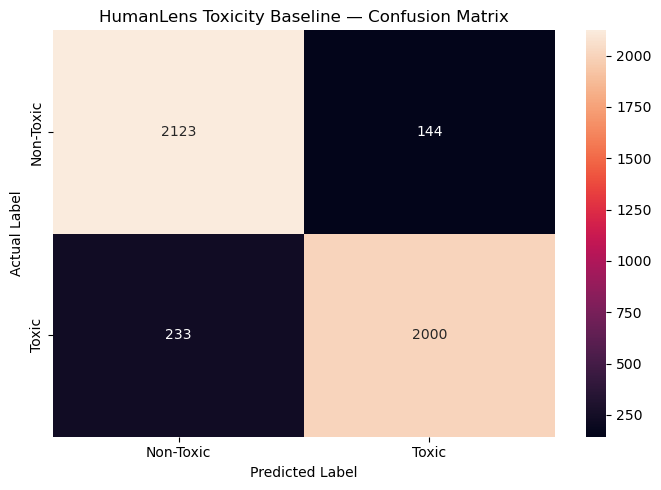

In [19]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-Toxic", "Toxic"],
    yticklabels=["Non-Toxic", "Toxic"]
)

plt.title("HumanLens Toxicity Baseline — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [20]:
language_results = []

for language in evaluation_df["language"].unique():

    subset = evaluation_df[
        evaluation_df["language"] == language
    ]

    y_true_lang = subset["toxicity_label"]
    y_pred_lang = subset["predicted_label"]

    language_results.append({
        "language": language,
        "samples": len(subset),
        "accuracy": accuracy_score(
            y_true_lang,
            y_pred_lang
        ),
        "precision": precision_score(
            y_true_lang,
            y_pred_lang,
            zero_division=0
        ),
        "recall": recall_score(
            y_true_lang,
            y_pred_lang,
            zero_division=0
        ),
        "f1": f1_score(
            y_true_lang,
            y_pred_lang,
            zero_division=0
        )
    })

language_results_df = pd.DataFrame(language_results)

language_results_df = language_results_df.sort_values(
    "f1",
    ascending=False
)

language_results_df

,language,samples,accuracy,precision,recall,f1
12,Tatar,300,0.993333,0.986577,1.000000,0.993243
5,French,300,0.990000,0.979167,1.000000,0.989474
11,Russian,300,0.990000,1.000000,0.978723,0.989247
13,Ukrainian,300,0.986667,0.992806,0.978723,0.985714
3,English,300,0.983333,0.985714,0.978723,0.982206
2,German,300,0.980000,1.000000,0.960000,0.979592
7,Hindi,300,0.970000,0.987013,0.955975,0.971246
4,Spanish,300,0.930000,0.992857,0.874214,0.929766
9,Italian,300,0.920000,0.959184,0.886792,0.921569
10,Japanese,300,0.910000,0.971429,0.855346,0.909699


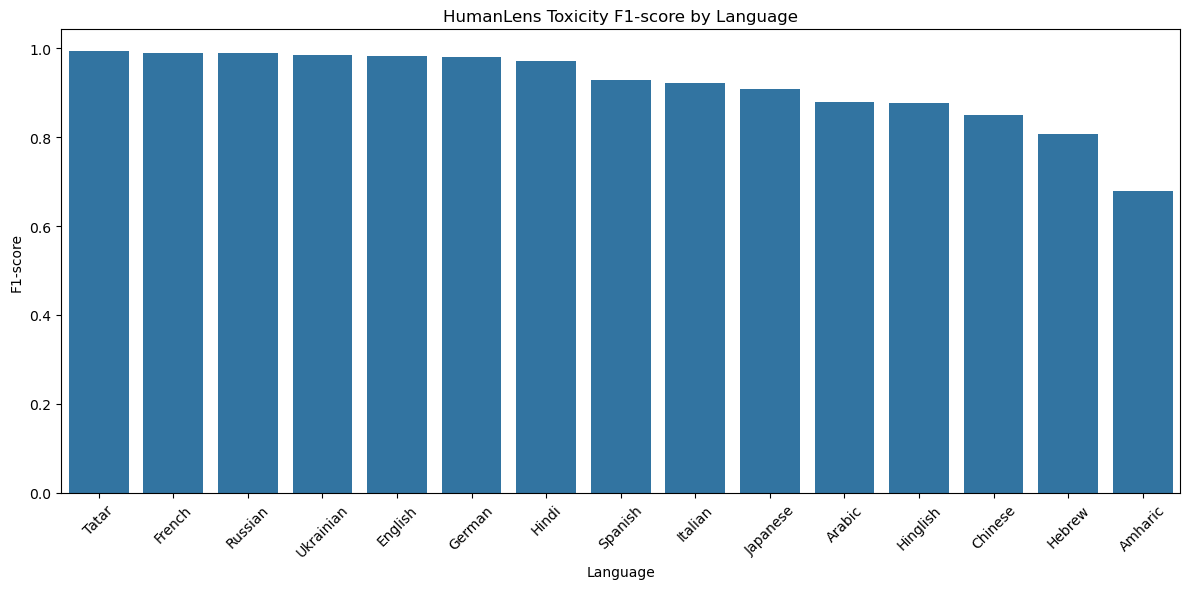

In [21]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=language_results_df,
    x="language",
    y="f1"
)

plt.title("HumanLens Toxicity F1-score by Language")
plt.xlabel("Language")
plt.ylabel("F1-score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
priority_languages = ["English", "Hindi", "Hinglish"]

priority_results = language_results_df[
    language_results_df["language"].isin(priority_languages)
].copy()

priority_results

,language,samples,accuracy,precision,recall,f1
3,English,300,0.983333,0.985714,0.978723,0.982206
7,Hindi,300,0.970000,0.987013,0.955975,0.971246
8,Hinglish,300,0.876667,0.850649,0.903448,0.876254


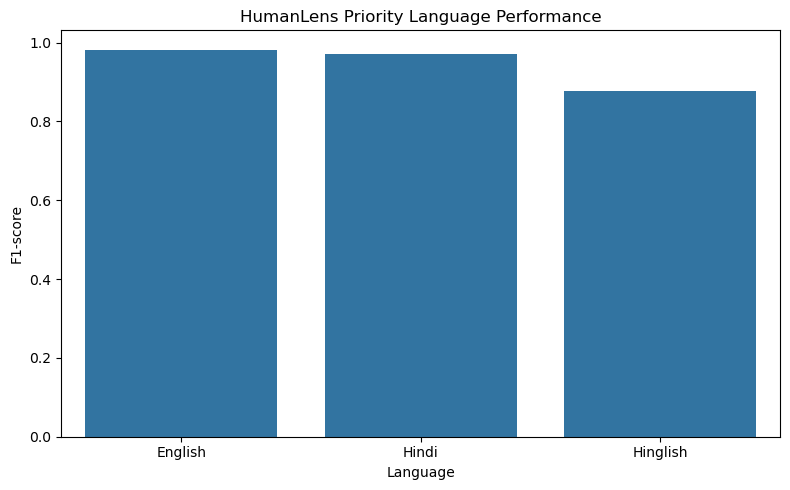

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=priority_results,
    x="language",
    y="f1"
)

plt.title("HumanLens Priority Language Performance")
plt.xlabel("Language")
plt.ylabel("F1-score")

plt.tight_layout()
plt.show()

In [24]:
false_positives = evaluation_df[
    (evaluation_df["toxicity_label"] == 0) &
    (evaluation_df["predicted_label"] == 1)
].copy()

print("False positives:", len(false_positives))

display(
    false_positives[
        [
            "language",
            "clean_text",
            "toxicity_label",
            "predicted_toxicity_score"
        ]
    ].head(20)
)

False positives: 144


,language,clean_text,toxicity_label,predicted_toxicity_score
4,Amharic,ምክንያቱም በገልም ቀረበ በወርቅ ሳሕን ግም ያው ግም ነው። እንዲያም አይ...,0,0.523765
5,Amharic,ከመሰከርክለት እቀበላለሁ። የእሱ እርዳታ መሰብሰብ ከገንዘቡ በላይ ስንት ...,0,0.533701
8,Amharic,ወይ ሰይጣን ሆይ የበደሉኝን ካፊሮች ሁሉ ወሰን በሌለው የገሃነም እሳት እረገም,0,0.529417
11,Amharic,So what’s the deal 3 ሰአት ከሆነ በኃላ የሚመጣ አናስተናግድም...,0,0.502112
15,Amharic,ዴሞክራሲ በጭቆና ላይ የታወጀ «ጦርነት» ነው። ፍትኅና እኩልነትም በልዩ ...,0,0.527104
18,Amharic,እንደግፋለን በሚገባ ጉራጌ ሀገር ቢመራ ስራ ያስተምርሀል እንጂ ጎጠኝነት ...,0,0.530792
20,Amharic,ማይካድራ በትህነግ የተፈፀመብኝን በደል አለም ይወቅልኝ ፣ የዘር ፍጅት ፈ...,0,0.532476
21,Amharic,ህፃናት ከተቀየሙህ በቃ አላነጋግርህም ተጣልቼሃለሁ እምቢየው ይሉሃል። እን...,0,0.532800
25,Amharic,ትግራይ ውስጥ እያየንና እየሰማነው ያለነውን መከራና ስቃይ ለመሸፈን መንግ...,0,0.532362
27,Amharic,ግራ የገባው አይምሮ ምንም አይነት ሳይንሳዊ እና አሳማኝ ምክንያት ስለሌለ...,0,0.532114


In [25]:
false_negatives = evaluation_df[
    (evaluation_df["toxicity_label"] == 1) &
    (evaluation_df["predicted_label"] == 0)
].copy()

print("False negatives:", len(false_negatives))

display(
    false_negatives[
        [
            "language",
            "clean_text",
            "toxicity_label",
            "predicted_toxicity_score"
        ]
    ].head(20)
)

False negatives: 233


,language,clean_text,toxicity_label,predicted_toxicity_score
16,Amharic,ወያኔ ጀግና ሁኖ አያውቅም: ቅዘናም ባንዳ እንጂ,1,0.485284
17,Amharic,ደንቆሮ።የትግራይ/ተጋሩ ደም በቤትክ ይፍሰስ።,1,0.463546
30,Amharic,ጋላ እሬቻውን ይዞ ቤተ መንግስት ገባ,1,0.455479
34,Amharic,በወራት ውስጥ የወያኔ አራዊትነትና ኢ-ኢትያዺያዊነት ተረሳ? ሱዳንና ወያኔ...,1,0.492971
38,Amharic,ደሞ ነጋላችሁ እናንተ የሀገሬ ጉዶች????,1,0.246123
42,Amharic,የጁንታውን መቃብር ለማየት የምንችልበት አመት ይሁንልን ። አሜን,1,0.499386
45,Amharic,ያው ናቸው ከወያኔ ጋር,1,0.350500
47,Amharic,የወያኔን መጨረሻ ነው ይምንመኘውና የምናየው ከነአስተሳስቡ ፈጣሪ ይገስፀው,1,0.499386
53,Amharic,አዲስ የስራ ማስታወቂያ ስራው ጁንታውን ማግኘት ነው ያገኘ 5ሚሊየን ብር ...,1,0.437064
65,Amharic,ፈጣሪ የጃቸውን ይስጣቸው እነዚህ አውሬዎች,1,0.390107


In [26]:
evaluation_df["error_type"] = "Correct"

evaluation_df.loc[
    (evaluation_df["toxicity_label"] == 0) &
    (evaluation_df["predicted_label"] == 1),
    "error_type"
] = "False Positive"

evaluation_df.loc[
    (evaluation_df["toxicity_label"] == 1) &
    (evaluation_df["predicted_label"] == 0),
    "error_type"
] = "False Negative"

error_by_language = pd.crosstab(
    evaluation_df["language"],
    evaluation_df["error_type"]
)

error_by_language

error_type,Correct,False Negative,False Positive
language,,,
Amharic,180,29,91
Arabic,265,34,1
Chinese,257,38,5
English,295,3,2
French,297,0,3
German,294,6,0
Hebrew,262,35,3
Hindi,291,7,2
Hinglish,263,14,23


In [27]:
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

language_results_path = (
    results_dir / "toxicity_baseline_language_results.csv"
)

language_results_df.to_csv(
    language_results_path,
    index=False
)

evaluation_path = (
    results_dir / "toxicity_baseline_predictions.csv"
)

evaluation_df.to_csv(
    evaluation_path,
    index=False
)

print("Results saved successfully.")
print(language_results_path)
print(evaluation_path)

Results saved successfully.
..\results\toxicity_baseline_language_results.csv
..\results\toxicity_baseline_predictions.csv


# Toxicity Baseline — Initial Findings

## Model

The HumanLens toxicity baseline uses a multilingual BERT-based
toxicity classifier fine-tuned on multilingual toxicity data.

## Evaluation

The model was evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Language-wise evaluation
- False-positive analysis
- False-negative analysis

## Multilingual Evaluation

Performance was evaluated separately across languages rather than
using only a single overall score.

Particular attention was given to:

- English
- Hindi
- Hinglish

This is important because multilingual toxicity performance can vary
substantially between languages.

## Error Analysis

False positives and false negatives were examined to identify
potential sources of model error.

Potential error categories to investigate include:

- Sarcasm
- Context dependence
- Profanity without harmful intent
- Code-mixed language
- Slang
- Ambiguous expressions
- Language-specific expressions

## Research Limitation

The baseline model is treated as an initial research baseline rather
than a final HumanLens toxicity model.

Its predictions should not be interpreted as definitive judgments
about a user's intentions, emotions, personality, or mental state.

Further threshold calibration, bias analysis and multimodal fusion
experiments are required before the toxicity score can be used in the
HumanLens escalation system.